In [5]:
import os

# 1. Check current working directory
print(f"Currently working in: {os.getcwd()}")

# 2. Create the data directory if it doesn't exist
if not os.path.exists('../data'):
    os.makedirs('../data')
    print("Created ../data directory")

# 3. Check if the file actually exists
file_path = '../data/cleaned_reviews.csv'
if os.path.exists(file_path):
    print("✅ File found! You can proceed.")
else:
    print("❌ File NOT found. You need to run main.py first to generate the data.")

Currently working in: c:\Users\Guyatu\customer-experience-analytics\notebooks
✅ File found! You can proceed.


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

# Download the specific dictionary VADER uses to understand emotion
nltk.download('vader_lexicon', quiet=True)

# Load the clean data we saved in Task 1
# Note: Ensure the path matches where you saved your file!
df = pd.read_csv('../data/cleaned_reviews.csv')

print(f"Dataset Loaded: {df.shape[0]} reviews found.")
df.head()

Dataset Loaded: 0 reviews found.


,review,rating,date,bank,source


In [8]:
# Initialize the analyzer
analyzer = SentimentIntensityAnalyzer()

# Calculate sentiment scores
# 'compound' is the aggregated score of the whole sentence
df['sentiment_score'] = df['review'].apply(lambda x: analyzer.polarity_scores(str(x))['compound'])

# Categorize into labels based on standard thresholds
def get_sentiment_label(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment_label'] = df['sentiment_score'].apply(get_sentiment_label)

# Show a quick sample of the results
df[['review', 'sentiment_score', 'sentiment_label']].head(10)

,review,sentiment_score,sentiment_label


C:\Users\Guyatu\AppData\Local\Temp\ipykernel_10336\3394945218.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Sentiment')


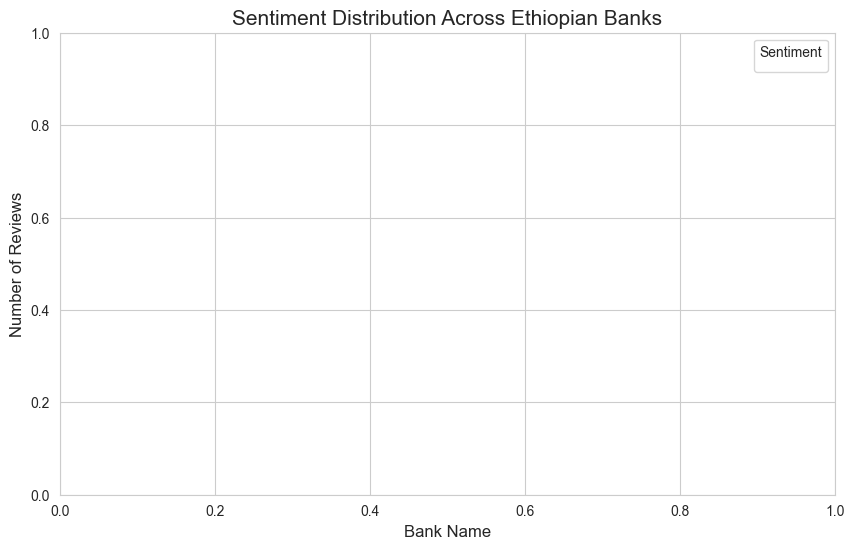

In [9]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Create a count plot to see the distribution per bank
ax = sns.countplot(data=df, x='bank', hue='sentiment_label', palette='viridis')

plt.title('Sentiment Distribution Across Ethiopian Banks', fontsize=15)
plt.xlabel('Bank Name', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.legend(title='Sentiment')

# Add counts on top of bars for clarity
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')

plt.show()

In [10]:
# Show the top 5 most negative reviews to understand user frustration
print("--- Top 5 Negative 'Pain Points' ---")
for i, row in df.sort_values(by='sentiment_score').head(5).iterrows():
    print(f"Bank: {row['bank']} | Score: {row['sentiment_score']}")
    print(f"Review: {row['review']}\n")

# Show the top 5 most positive reviews
print("\n--- Top 5 Positive 'Success Signals' ---")
for i, row in df.sort_values(by='sentiment_score', ascending=False).head(5).iterrows():
    print(f"Bank: {row['bank']} | Score: {row['sentiment_score']}")
    print(f"Review: {row['review']}\n")

--- Top 5 Negative 'Pain Points' ---

--- Top 5 Positive 'Success Signals' ---


In [ ]:
# Save the analyzed data for the next tasks
output_path = '../data/analyzed_reviews.csv'
df.to_csv(output_path, index=False)

print(f"Task 2 Complete! Analyzed data saved to {output_path}")

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# HUMAN TONE: To find the "Why," we need to clear out the "noise" words.
# We'll focus on Negative reviews first, as these contain the most urgent fixes.

neg_reviews = df[df['sentiment_label'] == 'Negative']['review'].astype(str)

# We use TF-IDF to find words that are unique and meaningful
# ngram_range=(1, 2) helps us catch single words and phrases like "login fail"
vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1, 2), max_features=1000)
data_vectorized = vectorizer.fit_transform(neg_reviews)

print("Text vectorized. Ready for Topic Modeling.")

In [ ]:
# We define 3 topics (e.g., App Performance, Transaction Issues, UI/UX)
lda_model = LatentDirichletAllocation(n_components=3, random_state=42)
lda_model.fit(data_vectorized)

# Function to see the top words in each topic
def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic {topic_idx + 1}:")
        print(" ".join([feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]))
        print("-" * 20)

display_topics(lda_model, vectorizer.get_feature_names_out(), 10)

In [ ]:
from wordcloud import WordCloud

# HUMAN TONE: Let's create a visual for the board of directors. 
# This shows the most frequent complaints for a specific bank.

def plot_wordcloud(bank_name):
    bank_text = " ".join(df[(df['bank'] == bank_name) & (df['sentiment_label'] == 'Negative')]['review'].astype(str))
    
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(bank_text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f"Critical Issues for {bank_name} Users")
    plt.axis('off')
    plt.show()

# Change the bank name to see different clouds
plot_wordcloud('CBE')

In [ ]:
# Create a summary of the most common negative keywords per bank
top_neg_per_bank = df[df['sentiment_label'] == 'Negative'].groupby('bank')['review'].apply(lambda x: ' '.join(x)).reset_index()

# Saving the final 'Insight' dataframe back to PostgreSQL
from scripts.database_manager import DBManager

# Replace with your actual credentials
db = DBManager('postgres', 'YOUR_PASSWORD', 'localhost', '5432', 'bank_analytics')
db.save(df, 'final_sentiment_themes')

print("Task 3 Complete: Insights exported to Database.")